Days in pepper data: [np.int64(0)]


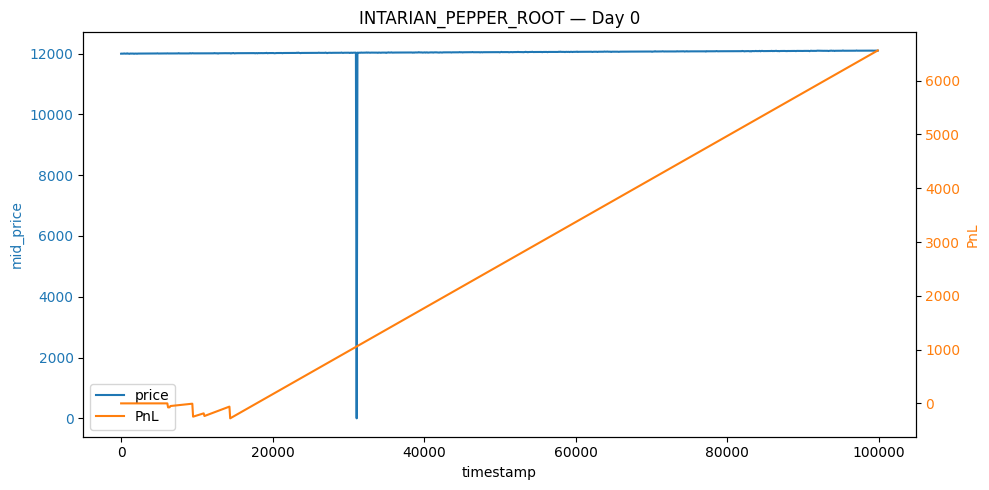

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

with open("198034.log", "r") as f:
    raw = f.read()

data = json.loads(raw)
csv_data = data["activitiesLog"]

df = pd.read_csv(StringIO(csv_data), sep=";")
df.columns = df.columns.str.strip()

pepper = df[df["product"] == "INTARIAN_PEPPER_ROOT"].copy()

for col in ["day", "timestamp", "mid_price", "profit_and_loss"]:
    pepper[col] = pd.to_numeric(pepper[col], errors="coerce")

pepper = pepper.dropna(subset=["day", "timestamp", "mid_price", "profit_and_loss"])

print("Days in pepper data:", sorted(pepper["day"].unique()))

for day in sorted(pepper["day"].unique()):
    day_data = pepper[pepper["day"] == day].sort_values("timestamp").reset_index(drop=True)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    l1 = ax1.plot(day_data["timestamp"], day_data["mid_price"], color="tab:blue", label="price")
    ax1.set_xlabel("timestamp")
    ax1.set_ylabel("mid_price", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    l2 = ax2.plot(day_data["timestamp"], day_data["profit_and_loss"], color="tab:orange", label="PnL")
    ax2.set_ylabel("PnL", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    plt.title(f"INTARIAN_PEPPER_ROOT — Day {int(day)}")
    plt.tight_layout()
    plt.show()

In [15]:
print(day_data[["timestamp", "mid_price", "profit_and_loss"]].head(20))
print(day_data[["timestamp", "mid_price", "profit_and_loss"]].tail(20))

    timestamp  mid_price  profit_and_loss
0           0    11998.5              0.0
1         100    12002.0              0.0
2         200    11999.0              0.0
3         300    12000.5              0.0
4         400    12007.0              0.0
5         500    12000.5              0.0
6         600    12000.5              0.0
7         700    12000.5              0.0
8         800    12010.0              0.0
9         900    12000.5              0.0
10       1000    12000.5              0.0
11       1100    11995.0              0.0
12       1200    12003.0              0.0
13       1300    12001.5              0.0
14       1400    12001.5              0.0
15       1500    12003.0              0.0
16       1600    12003.0              0.0
17       1700    11995.0              0.0
18       1800    12001.5              0.0
19       1900    12001.5              0.0
     timestamp  mid_price  profit_and_loss
980      98000    12098.0           6410.0
981      98100    12097.0       